# Algebra Linear

In [31]:
# função para salvar as figuras:
from pathlib import Path

import matplotlib.pyplot as plt

# Onde salvar as figuras geradas neste notebook.
IMAGES_PATH = Path("images") / "fundamentals"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

## Vetores

#### Representando vetores

Vetores são representados como listas de números, em que cada posição corresponde a uma dimensão ou atributo.

In [32]:
from typing import List

Vector = list[float]

height_weight_age = [70,    # Polegadas
                    170,    # Libras
                    50]     # Anos

grades = [95,   # Teste 1
          80,   # Teste 2
          75,   # Teste 3
          62]   # Teste 4


#### Visualizando a soma de vetores

Antes de implementar as operações, a soma é mostrada geometricamente no plano para reforçar a intuição visual.

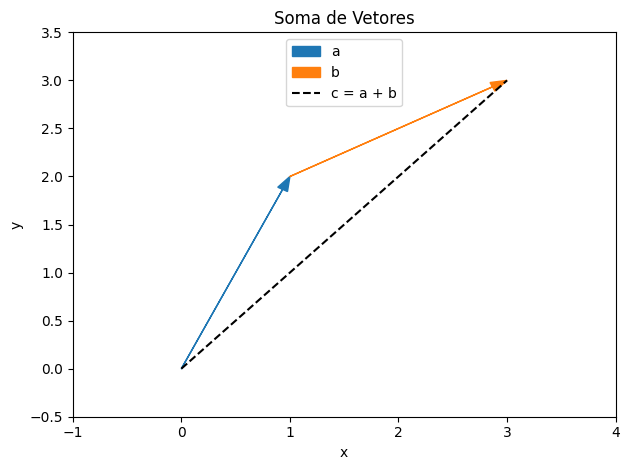

In [33]:
vetor_a = [1, 2]
vetor_b = [2, 1]
soma = [vetor_a[0] + vetor_b[0], vetor_a[1] + vetor_b[1]]

# vetor_a começa na origem
plt.arrow(0, 0, vetor_a[0], vetor_a[1],
          head_width=0.10, head_length=0.15,
          length_includes_head=True, color="tab:blue", label="a")

# vetor_b começa na ponta de vetor_a
plt.arrow(vetor_a[0], vetor_a[1], vetor_b[0], vetor_b[1],
          head_width=0.10, head_length=0.15,
          length_includes_head=True, color="tab:orange", label="b")

# a linha pontilhada mostra a soma vetor_a + vetor_b
plt.plot([0, soma[0]], [0, soma[1]], "k--", label="c = a + b")

plt.axis([-1, 4, -0.5, 3.5])
plt.xlabel("x")
plt.ylabel("y")
plt.title("Soma de Vetores")
plt.legend(loc=9)

save_fig("Figura 4-1. Somando dois vetores")
plt.show()


#### Operações básicas com vetores

As próximas funções combinam vetores elemento a elemento, multiplicam por escalares e calculam médias vetoriais.

In [34]:
def add(v: Vector, w: Vector) -> Vector:
    """Soma os elementos correspondentes"""
    assert len(v) == len(w), "vectors must be the same length"
    return [v_i + w_i for v_i, w_i in zip(v, w)]

assert add([1, 2, 3], [4, 5, 6]) == [5, 7, 9]

In [35]:
def subtract(v: Vector, w:Vector) -> Vector:
    """Subtrai os elementos correspondentes"""
    assert len(v) == len(w), "vectors must be the same length"
    return [v_i - w_i for v_i, w_i in zip(v, w)]

assert subtract([5, 7, 9], [4, 5, 6]) == [1, 2, 3]

In [36]:
def vector_sum(vectors: List[Vector]) -> Vector:
    """Soma todos os elementos correspondentes"""
    # Verifique se os vetores nao estao vazios
    assert vectors, "no vectors provided!" 

    # Verifique se os vetores sao do mesmo tamanho
    num_elements = len(vectors[0])
    assert all(len(v) == num_elements for v in vectors), "different sizes!"

    # O elemento de n i do resiltado e a soma de todo vector[i]
    return [sum(vector[i] for vector in vectors)
            for i in range(num_elements)]

assert vector_sum([[1, 2], [3, 4], [5, 6], [7, 8]]) == [16, 20]

In [37]:
def scalar_multiply(c: float, v: Vector) -> Vector:
    """Multiplica cada elemento por c"""
    return [c * v_i for v_i in v]

assert scalar_multiply(2, [1, 2, 3]) == [2, 4, 6]

In [38]:
def vector_mean(vectors: List[Vector]) -> Vector:
    """Computa a media dos elementos"""
    n = len(vectors)
    return scalar_multiply(1/n, vector_sum(vectors))

assert vector_mean([[1, 2], [3, 4], [5, 6]]) == [3, 4]

#### Produto escalar e projeção

O produto escalar combina dois vetores em um único número e ajuda a interpretar projeções e similaridade.

In [39]:
def dot(v: Vector, w: Vector) -> float:
    """Computa v_1 * w_1 + ... v_n * w_n"""
    assert len(v) == len(w), "vectors must be the same length"

    return sum(v_i * w_i for v_i, w_i in zip(v, w))

assert dot([1, 2, 3], [4, 5, 6]) == 32

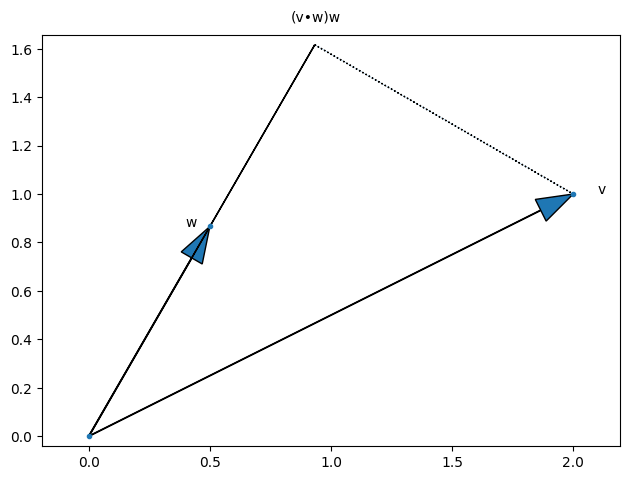

In [40]:
import math

v = [2, 1]
w = [math.sqrt(0.25), math.sqrt(0.75)]
c = dot(v, w)
v_sobre_w = scalar_multiply(c, w)
origem = [0, 0]

plt.arrow(0, 0, v[0], v[1],
          width=0.002, head_width=0.1,
          length_includes_head=True)
plt.annotate("v", v, xytext=[v[0] + 0.1, v[1]])

plt.arrow(0, 0, w[0], w[1],
          width=0.002, head_width=0.1,
          length_includes_head=True)
plt.annotate("w", w, xytext=[w[0] - 0.1, w[1]])

plt.arrow(0, 0, v_sobre_w[0], v_sobre_w[1],
          length_includes_head=True)
plt.annotate("(v•w)w", v_sobre_w,
             xytext=[v_sobre_w[0] - 0.1, v_sobre_w[1] + 0.1])

plt.arrow(v[0], v[1],
          v_sobre_w[0] - v[0], v_sobre_w[1] - v[1],
          linestyle="dotted", length_includes_head=True)

plt.scatter(*zip(v, w, origem), marker=".")
plt.axis("equal")

save_fig("Figura 4-2. O produto escalar como projecao de vetor")
plt.show()


#### Magnitude e distância

A magnitude mede o comprimento de um vetor; a distância entre dois vetores é calculada a partir da diferença entre eles.

In [41]:
def sum_of_squares(v: Vector) -> float:
    """Retorna v_1 *  v_1 + ... + v_n * v_n"""
    return dot(v, v)

assert sum_of_squares([1, 2, 3]) == 14

In [42]:
import math

def magnitude(v: Vector) -> float:
    """Retorna a magnitude (ou o comprimento) de v"""
    return math.sqrt(sum_of_squares(v))

assert magnitude([3, 4]) == 5

In [43]:
def squared_distance(v: Vector, w: Vector) -> float:
    """Computa (v_1 - w_1) ** 2 + ... + (v_n - w_n) ** 2"""
    return sum_of_squares(subtract(v, w))

def distance(v: Vector, w: Vector) -> float:
    """Computa a distancia entre v e w"""
    return math.sqrt(squared_distance(v, w))

In [44]:
def distance(v: Vector, w: Vector) -> float:
    return magnitude(subtract(v, w))

## Matriz

#### Representando matrizes

Matrizes são listas de listas, permitindo organizar valores em linhas e colunas.

In [45]:
# Outro alias de tipo
Matrix = List[List[float]]

A = [[1, 2, 3], # A tem duas linhas e tres colunas
     [4, 5, 6]]

B = [[1, 2],    # B tem tres linhas e duas colunas
     [3, 4],
     [5, 6]]

#### Forma, linhas e colunas

As funções desta parte identificam as dimensões da matriz e extraem linhas ou colunas específicas.

In [46]:
from typing import Tuple

def shape(A: Matrix) -> Tuple[int, int]:
    """Retorna (n de linhas de A, n de colunas de A)"""
    num_rows = len(A)
    num_cols = len(A[0]) if A else 0 
    return num_rows, num_cols 

assert shape([[1, 2, 3], [4, 5, 6]]) == (2, 3) # 2 linhas e 3 colunas


In [47]:
def get_row(A: Matrix, i: int) -> Vector:
    """Retorna a linha i de A (como um Vector)"""
    return A[i]

def get_column(A: Matrix, j: int) -> Vector:
    """Retorna a coluna j de A (como um Vector)"""
    return [A_i[j]
            for A_i in A]

#### Construindo matrizes

Uma matriz pode ser criada a partir de uma função que define o valor de cada posição.

In [48]:
from typing import Callable

def make_matrix(num_rows: int,
                num_cols: int,
                entry_fn: Callable[[int, int], float]) -> Matrix:
    """
    Retorna uma matrix num_rows x num_cols
    cuja entrada (i, j) eh entry_fn(i, j)
    """
    return [[entry_fn(i, j)
             for j in range(num_cols)]
             for i in range(num_rows)]

In [49]:
def identity_matrix(n: int) -> Matrix:
    """Retorna a matrz de identidade n x n"""
    return make_matrix(n, n, lambda i, j: 1 if i == j else 0)

assert identity_matrix(5) == [  [1, 0, 0, 0, 0],
                                [0, 1, 0, 0, 0],
                                [0, 0, 1, 0, 0],
                                [0, 0, 0, 1, 0],
                                [0, 0, 0, 0, 1]  ] 

#### Matriz de adjacência

A matriz de adjacência representa conexões entre usuários usando 1 para amizade e 0 para ausência de amizade.

In [50]:
friendships = [(0,1),(0,2),(1,2),(1,3),(2,3),(3,4),
                (4,5),(5,6),(5,7),(6,8),(7,8),(8,9)]

In [51]:
#       usuario  0  1  2  3  4  5  6  7  8  9
friend_matrix =[[0, 1, 1, 0, 0, 0, 0, 0, 0, 0], # usuario 0
                [1, 0, 1, 1, 0, 0, 0, 0, 0, 0], # usuario 1
                [1, 1, 0, 1, 0, 0, 0, 0, 0, 0], # usuario 2
                [0, 1, 1, 0, 1, 0, 0, 0, 0, 0], # usuario 3
                [0, 0, 0, 1, 0, 1, 0, 0, 0, 0], # usuario 4  
                [0, 0, 0, 0, 1, 0, 1, 1, 0, 0], # usuario 5
                [0, 0, 0, 0, 0, 1, 0, 0, 1, 0], # usuario 6 
                [0, 0, 0, 0, 0, 1, 0, 0, 1, 0], # usuario 7
                [0, 0, 0, 0, 0, 0, 1, 1, 0, 1], # usuario 8
                [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],]# usuario 9

In [52]:
assert friend_matrix[0][2] == 1, "0 and 2 are friends"
assert friend_matrix[0][8] == 0, "0 and 8 are not friends"


In [53]:
# basta nalisar uma linha
frineds_of_five = [i 
                   for i, is_friend in enumerate(friend_matrix[5])
                   if is_friend]
frineds_of_five

[4, 6, 7]